# Comparaison et analyse des modèles
Ce notebook charge tous les modèles entraînés et les compare via :
- Un tableau récapitulatif de toutes les métriques
- Les courbes ROC et Précision-Recall superposées
- Les matrices de confusion
- L'analyse du seuil de décision
- Les importances des variables
- Les métriques par mois sur le jeu de test 2025

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    recall_score, precision_score,
    f1_score, fbeta_score, matthews_corrcoef,
    brier_score_loss, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay,
    classification_report, precision_recall_curve,
)

os.chdir('/home/onyxia/work/bdc-apicil-g1')

from src.model import FEATURES, split_data, load_model

## Chargement des données et split

In [2]:
df = pd.read_csv('data/processed/panel_final.csv', low_memory=False)
df['date_reference'] = pd.to_datetime(df['date_reference'])

x_train, x_test, y_train, y_test = split_data(df)

def clean_feature_names(dataframe):
    """Remplace les caractères spéciaux dans les noms de colonnes par des underscores."""
    dataframe = dataframe.copy()
    dataframe.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col) for col in dataframe.columns
    ]
    return dataframe

x_test_lgbm = clean_feature_names(x_test)

# Mois de la date de référence sur le jeu de test (sans modifier x_test)
test_df  = df[df['date_reference'].dt.year >= 2025].copy()
mois_test = test_df['mois_reference'].values

# Features sans INSEE
cols_insee = [col for col in df.columns if 'indice' in col or 'chomage' in col]
FEATURES_SANS_INSEE = [f for f in FEATURES if f not in cols_insee]

x_train_si, x_test_si, _, _ = split_data(df, features=FEATURES_SANS_INSEE)
x_test_si_lgbm = clean_feature_names(x_test_si)

Train : 1,001,183 observations (2.40% de résiliations)
Test  : 382,343 observations (1.75% de résiliations)
Train : 1,001,183 observations (2.40% de résiliations)
Test  : 382,343 observations (1.75% de résiliations)


In [3]:
xgb  = load_model('xgboost')
xgb_insee = load_model('xgboost_insee')
lgbm = load_model('lightgbm')
lgbm_insee = load_model('lightgbm_insee')
rf   = load_model('random_forest')
rf_insee =load_model('random_forest_insee')

models = {
    'XGBoost':       (xgb,  x_test_si),
    'XGBoost INSEE':       (xgb_insee,  x_test),
    'LightGBM':      (lgbm, x_test_si_lgbm),
    'LightGBM INSEE':      (lgbm_insee, x_test_lgbm),
    'Random Forest': (rf,   x_test_si),
    'Random Forest INSEE': (rf_insee,   x_test)
}

# Calcul des probabilités et prédictions pour tous les modèles
probas = {}
preds  = {}
for name, (model, x) in models.items():
    probas[name] = model.predict_proba(x)[:, 1]
    preds[name]  = (probas[name] >= 0.5).astype(int)

Modèle chargé depuis models/auc_roc/xgboost.pkl
Modèle chargé depuis models/auc_roc/xgboost_insee.pkl
Modèle chargé depuis models/auc_roc/lightgbm.pkl
Modèle chargé depuis models/auc_roc/lightgbm_insee.pkl
Modèle chargé depuis models/auc_roc/random_forest.pkl
Modèle chargé depuis models/auc_roc/random_forest_insee.pkl


## 1. Tableau récapitulatif des métriques

In [4]:
rows = []
for name in models:
    y_proba = probas[name]
    y_pred  = preds[name]
    rows.append({
        'Modèle':    name,
        'AUC-ROC':   round(roc_auc_score(y_test, y_proba), 4),
        'AUC-PR':    round(average_precision_score(y_test, y_proba), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'Précision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
        'F2':        round(fbeta_score(y_test, y_pred, beta=2, zero_division=0), 4),
        'MCC':       round(matthews_corrcoef(y_test, y_pred), 4),
        'Brier':     round(brier_score_loss(y_test, y_proba), 4),
    })

results = pd.DataFrame(rows).set_index('Modèle')
results

,AUC-ROC,AUC-PR,Recall,Précision,F1,F2,MCC,Brier
Modèle,,,,,,,,
XGBoost,0.3161,0.0116,0.0000,0.0000,0.0000,0.0000,0.0000,0.0177
XGBoost INSEE,0.9453,0.2224,0.7929,0.1931,0.3106,0.4891,0.3726,0.0506
LightGBM,0.4208,0.0142,0.0589,0.0091,0.0157,0.0280,-0.0232,0.0940
LightGBM INSEE,0.9515,0.1907,0.8045,0.1676,0.2774,0.4571,0.3466,0.0562
Random Forest,0.4465,0.0157,0.0018,0.0013,0.0015,0.0017,-0.0198,0.0757
Random Forest INSEE,0.7343,0.0371,0.0631,0.0333,0.0435,0.0535,0.0222,0.1068


## 3. Matrices de confusion

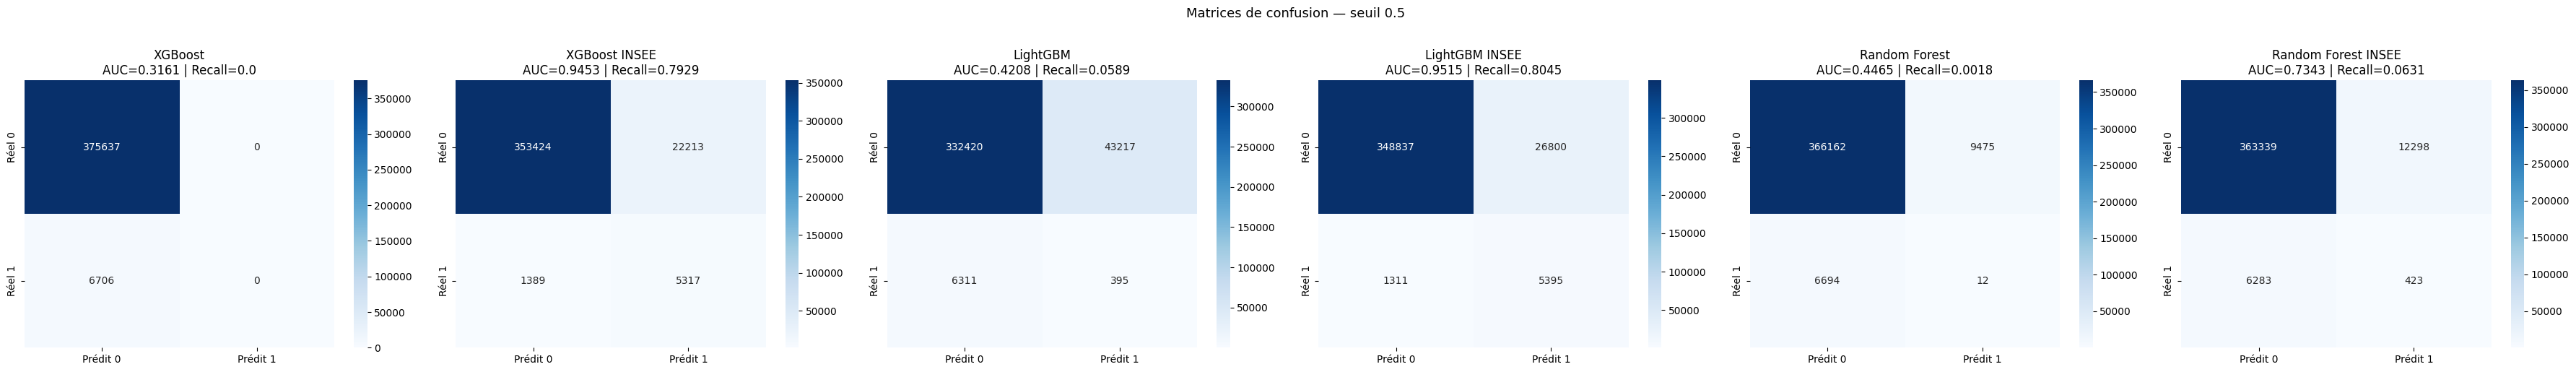

In [5]:
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))

for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, preds[name])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Prédit 0', 'Prédit 1'],
        yticklabels=['Réel 0', 'Réel 1'],
    )
    ax.set_title(
        f'{name}\n'
        f'AUC={results.loc[name, "AUC-ROC"]} | '
        f'Recall={results.loc[name, "Recall"]}'
    )

plt.suptitle('Matrices de confusion — seuil 0.5', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Importance des variables — top 20 par modèle

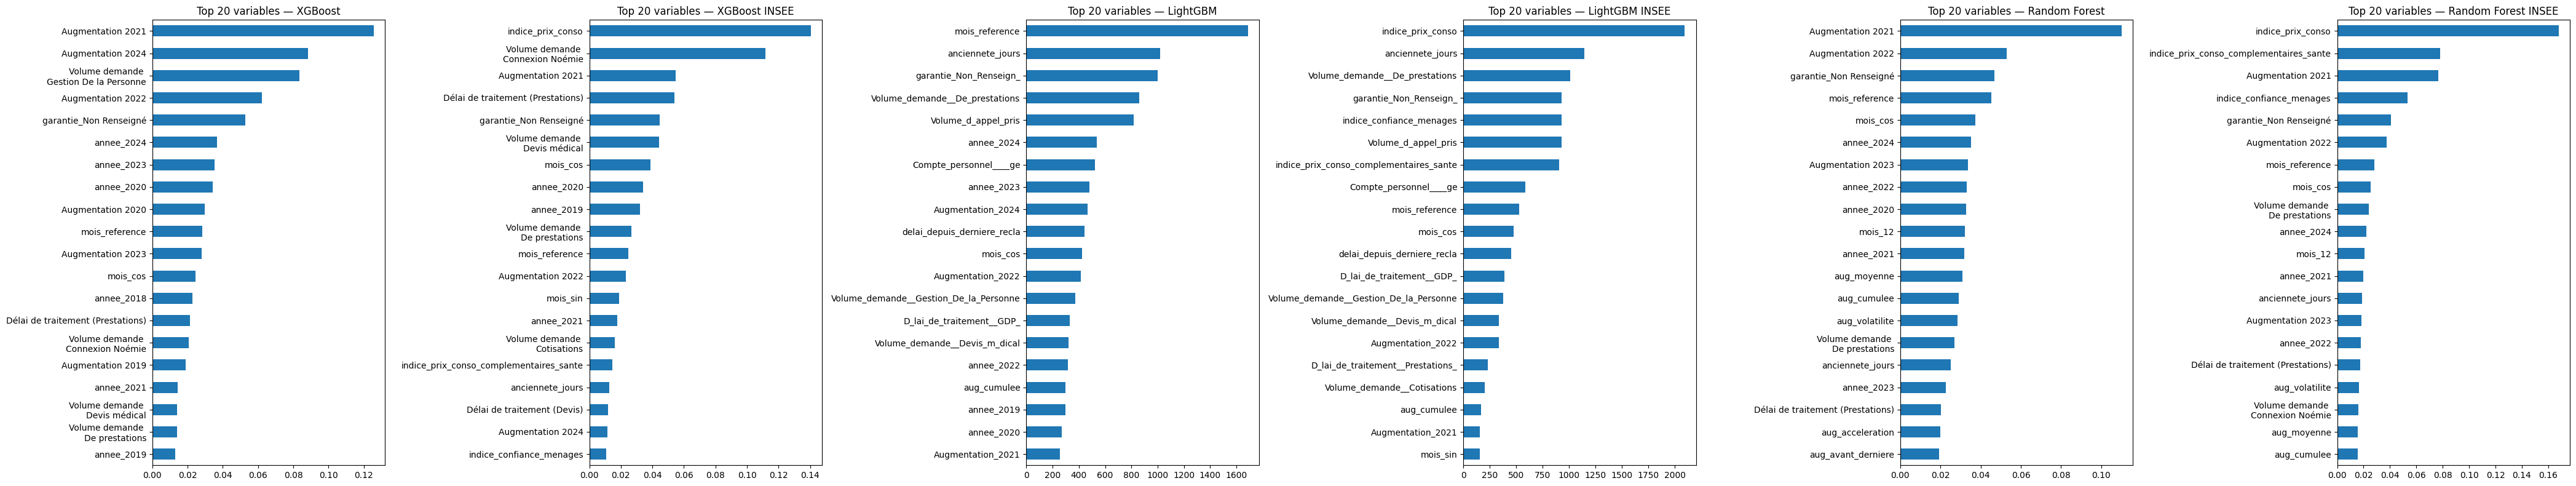

In [6]:
fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 8))

for ax, (name, (model, x)) in zip(axes, models.items()):
    importances = pd.Series(model.feature_importances_, index=x.columns)
    importances.sort_values(ascending=False).head(20).plot(kind='barh', ax=ax)
    ax.invert_yaxis()
    ax.set_title(f'Top 20 variables — {name}')

plt.tight_layout()
plt.savefig('reports/figures/feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Métriques par mois sur le jeu de test 2025

In [7]:
all_results = []

for model_name in models:
    y_proba = probas[model_name]
    y_pred  = preds[model_name]

    for m in sorted(np.unique(mois_test)):
        mask = (mois_test == m)
        if mask.sum() == 0:
            continue

        y_true_m = y_test.values[mask]
        y_pred_m = y_pred[mask]
        y_prob_m = y_proba[mask]

        try:
            auc = roc_auc_score(y_true_m, y_prob_m)
        except ValueError:
            auc = np.nan

        all_results.append({
            'modele':    model_name,
            'mois':      m,
            'auc':       auc,
            'recall':    recall_score(y_true_m, y_pred_m, zero_division=0),
            'precision': precision_score(y_true_m, y_pred_m, zero_division=0),
            'f1':        f1_score(y_true_m, y_pred_m, zero_division=0),
            'f2':        fbeta_score(y_true_m, y_pred_m, beta=2, zero_division=0),
            'n_obs':     mask.sum(),
            'n_resilie': y_true_m.sum(),
        })

results_month = pd.DataFrame(all_results)
results_month

,modele,mois,auc,recall,precision,f1,f2,n_obs,n_resilie
0,XGBoost,1,0.213716,0.000000,0.000000,0.000000,0.000000,24469,950
1,XGBoost,2,0.220829,0.000000,0.000000,0.000000,0.000000,26154,895
2,XGBoost,3,0.365388,0.000000,0.000000,0.000000,0.000000,27997,830
3,XGBoost,4,0.425932,0.000000,0.000000,0.000000,0.000000,29867,853
4,XGBoost,5,0.360605,0.000000,0.000000,0.000000,0.000000,31095,501
...,...,...,...,...,...,...,...,...,...
67,Random Forest INSEE,8,0.739652,0.022684,0.020202,0.021371,0.022140,34091,529
68,Random Forest INSEE,9,0.785355,0.069395,0.053498,0.060418,0.065502,34683,562
69,Random Forest INSEE,10,0.812498,0.060686,0.033724,0.043355,0.052320,35231,379
70,Random Forest INSEE,11,0.845228,0.166667,0.001067,0.002121,0.005203,35961,6


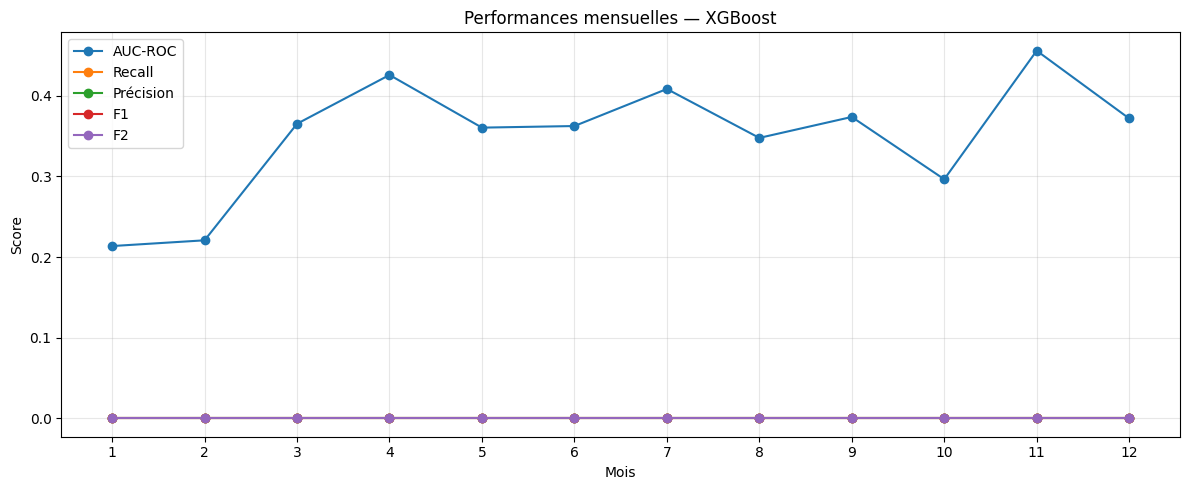

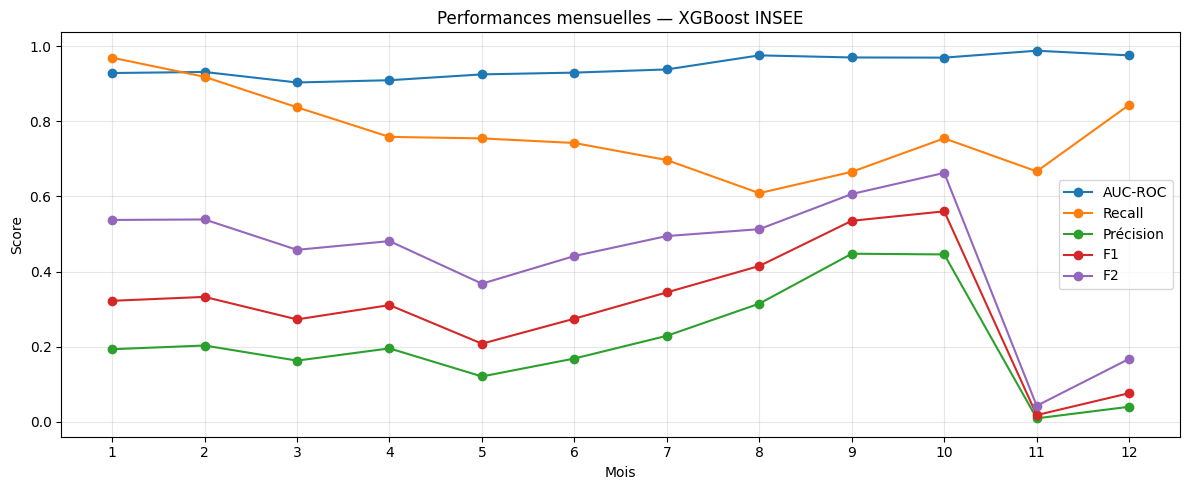

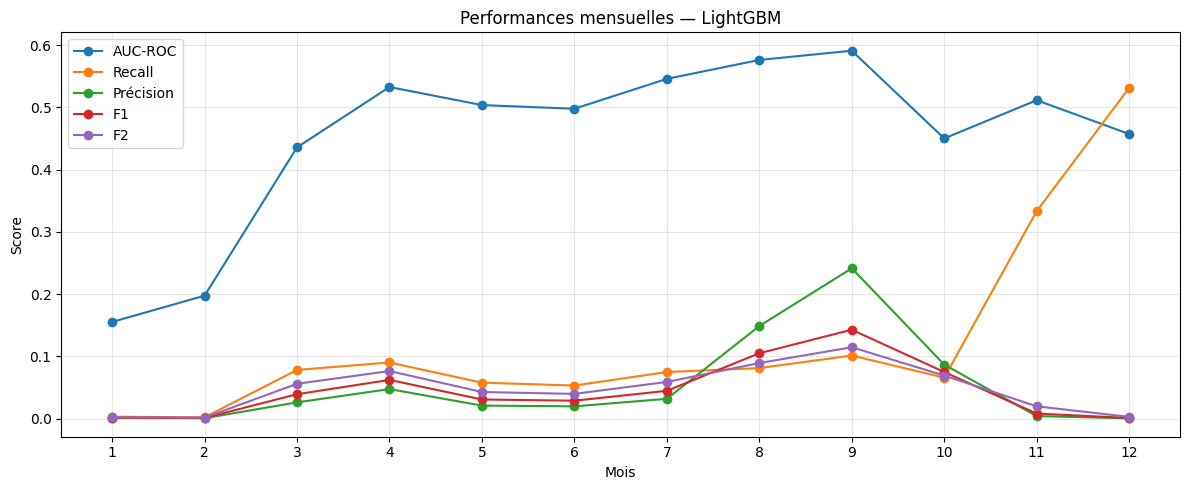

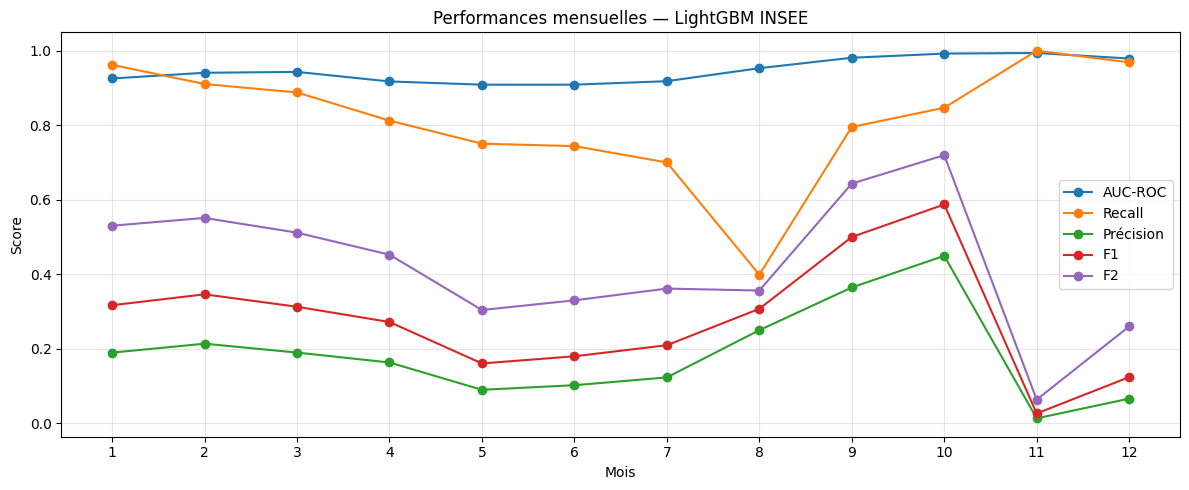

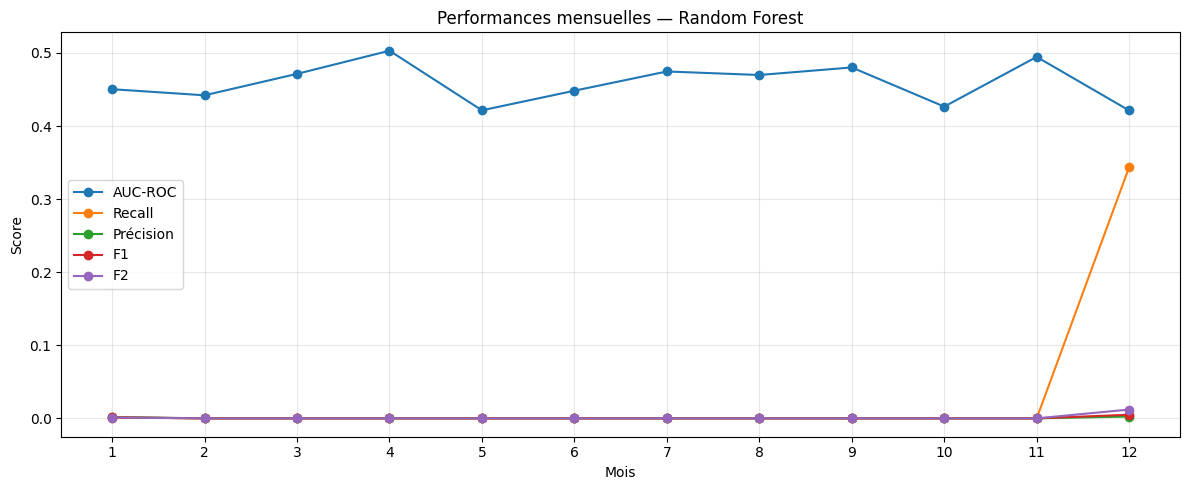

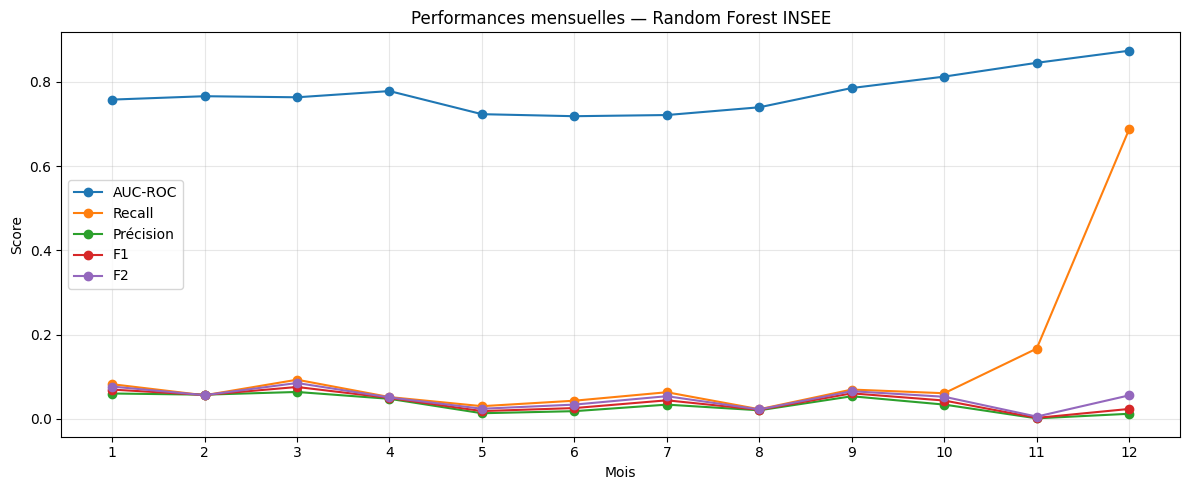

In [10]:
for model_name in results_month['modele'].unique():
    subset = results_month[results_month['modele'] == model_name]

    fig, ax = plt.subplots(figsize=(12, 5))

    for metrique, titre in zip(metriques, titres):
        ax.plot(subset['mois'], subset[metrique], marker='o', label=titre)

    ax.set_title(f'Performances mensuelles — {model_name}')
    ax.set_xlabel('Mois')
    ax.set_ylabel('Score')
    ax.set_xticks(range(1, 13))
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'reports/figures/metrics_by_month_{model_name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()